# Stock price prediction using simple ML techniques 

In [ ]:
! pip install numpy pandas matplotlib scikit-learn pandas_ta seaborn

  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 3.4 MB/s eta 0:00:00a 0:00:01
  Using cached pillow-12.1.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  

## Import basic libraries and check the dataset structure

In [15]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns

## Load dataset

Do correct typing of all values and calculate the minimum and maximum values in the `Date` column to identify the span of the dataset.

In [12]:
raw_data = pd.read_csv('NVDA.csv', parse_dates=['Date'])
raw_data['Close'] = raw_data['Close'].astype(float)
raw_data['High'] = raw_data['High'].astype(float)
raw_data['Low'] = raw_data['Low'].astype(float)
raw_data['Volume'] = raw_data['Volume'].astype(float)

print("Date range:", raw_data['Date'].min().date(), "->", raw_data['Date'].max().date())
print("Raw shape:", raw_data.shape)
raw_data.head()

Date range: 1999-01-22 -> 2025-02-14
Raw shape: (6558, 7)


,Date,Adj Close,Close,High,Low,Open,Volume
0,1999-01-22,0.037615,0.041016,0.048828,0.038802,0.043750,2.714688e+09
1,1999-01-25,0.041556,0.045313,0.045833,0.041016,0.044271,5.104800e+08
2,1999-01-26,0.038331,0.041797,0.046745,0.041146,0.045833,3.432000e+08
3,1999-01-27,0.038212,0.041667,0.042969,0.039583,0.041927,2.443680e+08
4,1999-01-28,0.038092,0.041536,0.041927,0.041276,0.041667,2.275200e+08


## Simple Technical Indicator

Simply compute technical indicator using pandas_ta

In [13]:
df = raw_data.copy()

df['SMA_20'] = ta.sma(df['Close'], length=20)
df['SMA_50'] = ta.sma(df['Close'], length=50)
df['EMA_12'] = ta.ema(df['Close'], length=12)
df['EMA_26'] = ta.ema(df['Close'], length=26)
df['RSI'] = ta.rsi(df['Close'], length=14)

macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
df['MACD'] = macd['MACD_12_26_9']
df['MACD_Signal'] = macd['MACDs_12_26_9']

bb = ta.bbands(df['Close'], length=20)
df['BB_Lower'] = bb.iloc[:, 0]
df['BB_Mid'] = bb.iloc[:, 1]
df['BB_Upper'] = bb.iloc[:, 2]

df['ATR'] = ta.atr(high=df['High'], low=df['Low'], close=df['Close'], length=14)

stoch = ta.stoch(high=df['High'], low=df['Low'], close=df['Close'], k=14, d=3)
df['Stoch_K'] = stoch['STOCHk_14_3_3']
df['Stoch_D'] = stoch['STOCHd_14_3_3']

df['OBV'] = ta.obv(df['Close'], df['Volume'])
df['CCI'] = ta.cci(high=df['High'], low=df['Low'], close=df['Close'], length=20)
df['ROC'] = ta.roc(df['Close'], length=12) * 100  # expressed as %

print("Shape after indicators:", df.shape)
df[['Date','Close','SMA_20','EMA_12','RSI','MACD','ATR','OBV']].tail(5)

Shape after indicators: (6558, 23)


,Date,Close,SMA_20,EMA_12,RSI,MACD,ATR,OBV
6553,2025-02-10,133.570007,130.915501,128.353280,51.981874,-2.826277,6.859995,1.587528e+11
6554,2025-02-11,132.800003,130.894001,129.037391,51.280517,-2.262199,6.617138,1.585739e+11
6555,2025-02-12,131.139999,130.863002,129.360869,49.722957,-1.926899,6.410199,1.584136e+11
6556,2025-02-13,135.289993,130.815501,130.273042,53.523526,-1.311187,6.335185,1.586110e+11
6557,2025-02-14,138.850006,131.079501,131.592575,56.557309,-0.529860,6.165530,1.588059e+11


## Visualise indicators
Yea... Well... Visualisation...

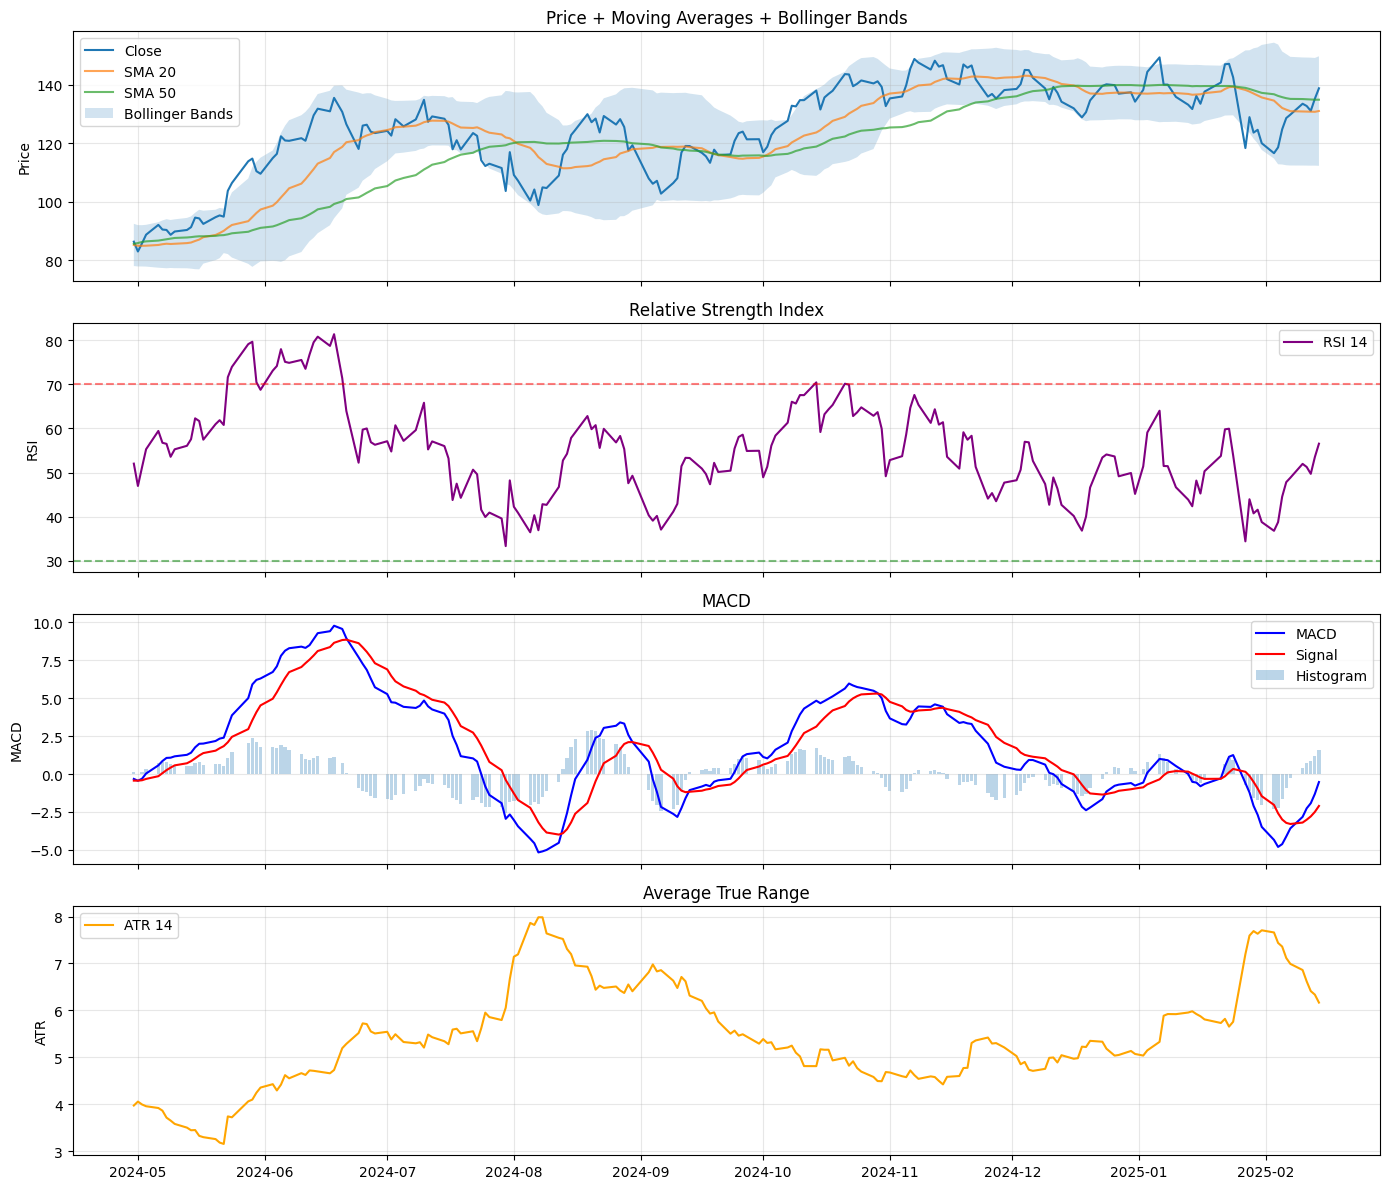

In [16]:
plot_data = df.tail(200)
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(plot_data['Date'], plot_data['Close'], label='Close', linewidth=1.5)
axes[0].plot(plot_data['Date'], plot_data['SMA_20'], label='SMA 20', alpha=0.7)
axes[0].plot(plot_data['Date'], plot_data['SMA_50'], label='SMA 50', alpha=0.7)
axes[0].fill_between(plot_data['Date'], plot_data['BB_Upper'], plot_data['BB_Lower'], alpha=0.2, label='Bollinger Bands')
axes[0].set_ylabel('Price'); axes[0].set_title('Price + Moving Averages + Bollinger Bands')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_data['Date'], plot_data['RSI'], color='purple', label='RSI 14')
axes[1].axhline(70, color='r', linestyle='--', alpha=0.5)
axes[1].axhline(30, color='g', linestyle='--', alpha=0.5)
axes[1].set_ylabel('RSI'); axes[1].set_title('Relative Strength Index')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(plot_data['Date'], plot_data['MACD'], label='MACD', color='blue')
axes[2].plot(plot_data['Date'], plot_data['MACD_Signal'], label='Signal', color='red')
axes[2].bar(plot_data['Date'], plot_data['MACD'] - plot_data['MACD_Signal'], alpha=0.3, label='Histogram')
axes[2].set_ylabel('MACD'); axes[2].set_title('MACD')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

axes[3].plot(plot_data['Date'], plot_data['ATR'], color='orange', label='ATR 14')
axes[3].set_ylabel('ATR'); axes[3].set_title('Average True Range')
axes[3].legend(); axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Target Engineering

Predict whether the price 30 days from now is HIGHER than today
- Label = 1 if ROC(t+30) > 0 else 0

In [ ]:
print(f"NaNs before cleaning: {df.isna().sum().sum()}")
df.dropna(inplace=True)
df = df.sort_values('Date').reset_index(drop=True)
print(f"NaNs after cleaning:  {df.isna().sum().sum()}")

df['ROC_30d_future']      = df['ROC'].shift(-30)
df['Price_Direction_30d'] = (df['ROC_30d_future'] > 0).astype(int)

df.dropna(subset=['ROC_30d_future'], inplace=True)
df.drop(columns=['ROC_30d_future'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape after target engineering:", df.shape)
print("\nClass distribution:")
print(df['Price_Direction_30d'].value_counts(normalize=True).round(3))

NaNs before cleaning: 297
NaNs after cleaning:  0
Shape after target engineering: (6479, 24)

Class distribution:
Price_Direction_30d
1    0.573
0    0.427
Name: proportion, dtype: float64


## Class distribution plot

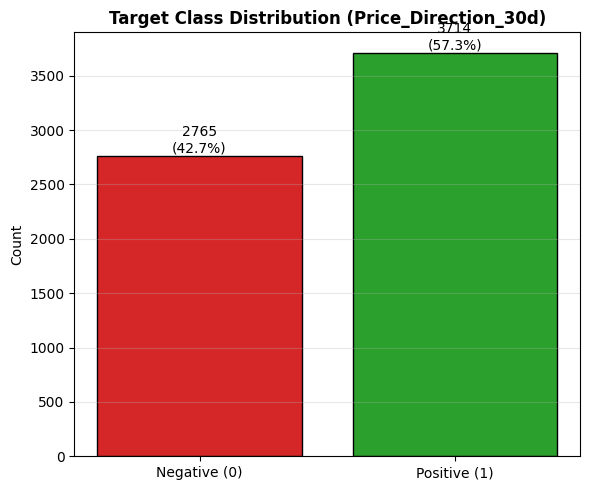

In [18]:
class_dist = df['Price_Direction_30d'].value_counts().sort_index()
class_pct  = df['Price_Direction_30d'].value_counts(normalize=True).sort_index() * 100
labels     = ['Negative (0)', 'Positive (1)']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, [class_dist[0], class_dist[1]], color=['#d62728', '#2ca02c'], edgecolor='black')

for bar, lbl in zip(bars, [0, 1]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{class_dist[lbl]}\n({class_pct[lbl]:.1f}%)", ha='center', va='bottom')
    
ax.set_title('Target Class Distribution (Price_Direction_30d)', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Yearly class distribution

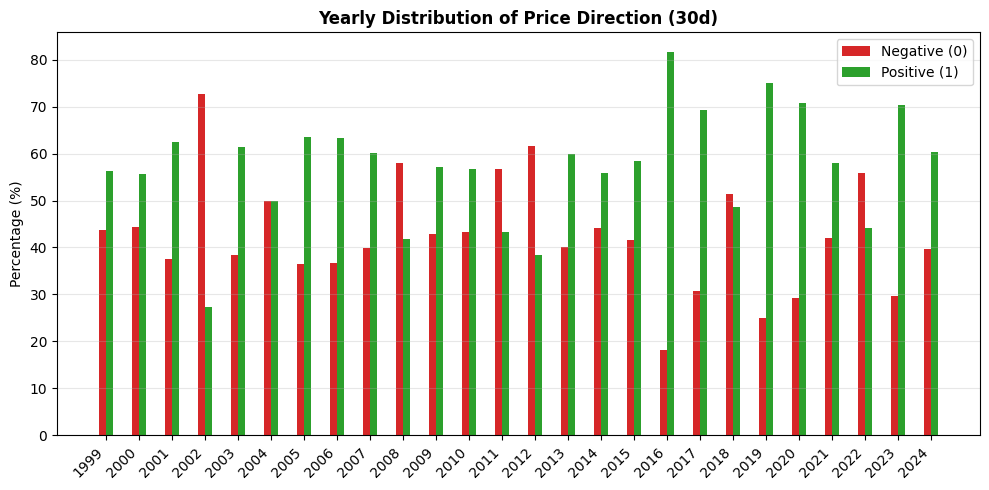

In [19]:
df['Year'] = df['Date'].dt.year
yearly_pct = pd.crosstab(df['Year'], df['Price_Direction_30d'], normalize='index') * 100
yearly_pct = yearly_pct.reindex(columns=[0, 1], fill_value=0)

spacing = 1.6
x     = [i * spacing for i in range(len(yearly_pct))]
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], yearly_pct[0], width, label='Negative (0)', color='#d62728')
ax.bar([i + width/2 for i in x], yearly_pct[1], width, label='Positive (1)',  color='#2ca02c')
ax.set_xticks(x)
ax.set_xticklabels(yearly_pct.index.astype(int), rotation=45, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Yearly Distribution of Price Direction (30d)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df.drop(columns=['Year'], inplace=True)

## ROC descriptive statistics

In [20]:
roc = df['ROC'].dropna()
print("=" * 50)
print("ROC (12-period) DESCRIPTIVE STATISTICS")
print("=" * 50)
stats = {
    'Mean': roc.mean(), 'Median': roc.median(), 'Std Dev': roc.std(),
    'Skewness': roc.skew(), 'Kurtosis': roc.kurtosis(),
    'Min': roc.min(), 'Max': roc.max(),
    'IQR': roc.quantile(0.75) - roc.quantile(0.25)
}
for k, v in stats.items():
    print(f"  {k:<12} {v:>10.4f}")

ROC (12-period) DESCRIPTIVE STATISTICS
  Mean           233.7044
  Median         184.4720
  Std Dev       1312.5185
  Skewness         0.7021
  Kurtosis         4.5830
  Min          -5471.2797
  Max          12873.5153
  IQR           1364.5510


## Full correlation matrix (all computed features)

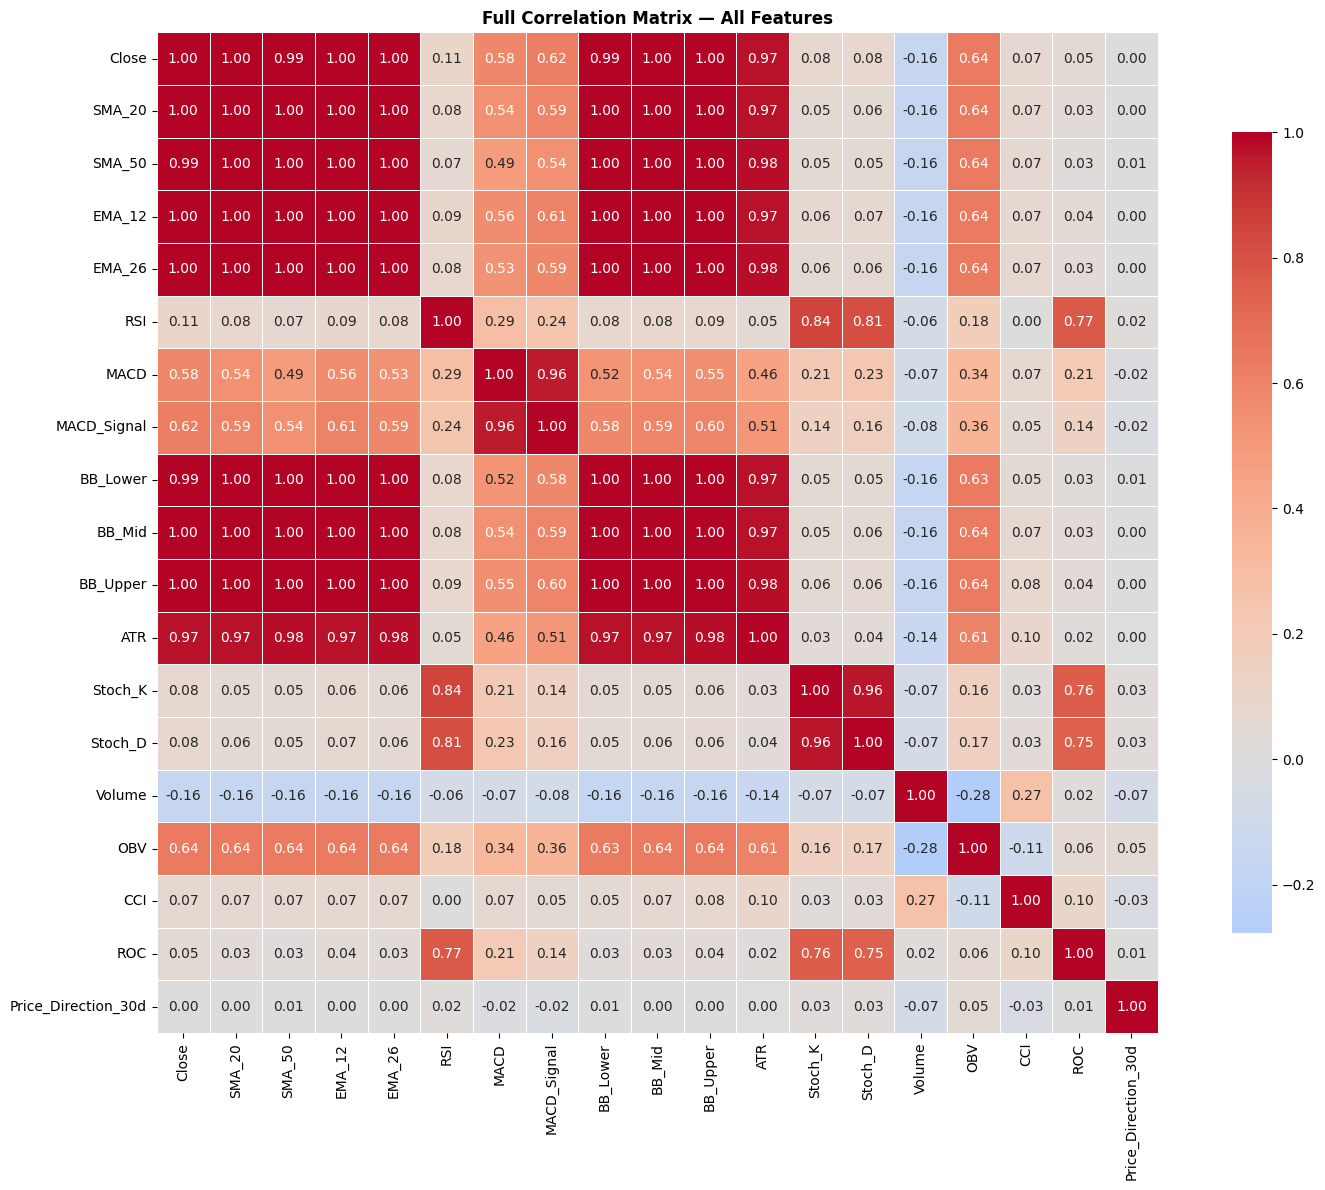

In [24]:
all_features = ['Close', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26',
                'RSI', 'MACD', 'MACD_Signal', 'BB_Lower', 'BB_Mid', 'BB_Upper',
                'ATR', 'Stoch_K', 'Stoch_D', 'Volume', 'OBV', 'CCI', 'ROC',
                'Price_Direction_30d']

corr_full = df[all_features].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Full Correlation Matrix — All Features', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

##  Feature selection: drop multicollinear features

- Close, SMA_20, SMA_50, EMA_12, EMA_26 — price-level values, near-perfect (ATR will be picked instead)
     correlation with each other (|r| > 0.99). Encode no new information.

- MACD — highly correlated with MACD_Signal, clear mathematically why. Keep only MACD_Signal
     
- BB_Mid, BB_Upper, BB_Lower — nearly identical to SMA, EMA

- OBV — raw cumulative sum, grows monotonically with time (non-stationary).
     High correlation with Close for trending stocks like NVDA.

- Stoch_D — 3-period SMA of Stoch_K. Near-duplicate of Stoch_K (|r| typically > 0.95).

- Volume — kept only if you add a volume-derived ratio; raw volume is non-stationary.

**Features kept — independent, bounded/normalised signals:**
 - RSI, MACD_Signal, ATR, Stoch_K, CCI, ROC

In [ ]:
FEATURES = ['RSI', 'MACD_Signal', 'ATR', 'Stoch_K', 'CCI', 'ROC']
TARGET = 'Price_Direction_30d'

# low correlation with target as the correlation is not linear
print("Selected features:", FEATURES)
print(f"\nCorrelation among selected features with target ({TARGET}):")
corr_selected = df[FEATURES + [TARGET]].corr()
print(corr_selected[TARGET].drop(TARGET).sort_values(ascending=False).to_string())

Selected features: ['RSI', 'MACD_Signal', 'ATR', 'Stoch_K', 'CCI', 'ROC']

Correlation among selected features with target (Price_Direction_30d):
Stoch_K        0.031684
RSI            0.022851
ROC            0.009055
ATR            0.000934
MACD_Signal   -0.023323
CCI           -0.033284


## Correlation with new features

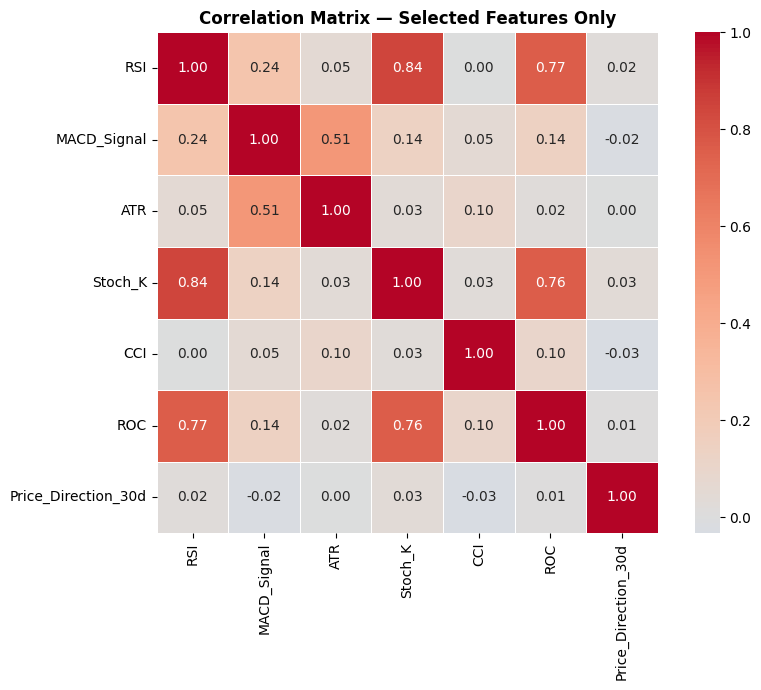

In [26]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr_selected, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Selected Features Only', fontweight='bold')
plt.tight_layout()
plt.show()

## Save new dataset

In [ ]:
corr_selected.to_csv('selected_features_correlation.csv', index=True)